# ArcFace + LSTM Personality Prediction - Fixed

| Perubahan | Sebelum | Sesudah | Alasan |
|---|---|---|---|
| L2 Regularization | `l2(0.01)` | `l2(1e-4)` | L2=0.01 terlalu kuat → output selalu sama |
| Dense Layers | `(1024,512,256)` | `(256,128)` | Proporsional dengan data kecil (100 video) |
| LSTM Dropout | Tidak ada | `recurrent_dropout=0.2` | Regularisasi temporal LSTM |
| Validation | `.shuffle()` | Tanpa shuffle | Validation tidak boleh di-shuffle |
| EarlyStopping | Tanpa `restore_best_weights` | `restore_best_weights=True` | Simpan model terbaik, bukan terakhir |

In [1]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import mean_absolute_error
import numpy as np
import datetime
import os

from models import create_arcface_model, create_arcface_personality_model

print(f'TensorFlow version: {tf.__version__}')

c:\Users\ALFIAN\anaconda3\envs\env_insightface\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\ALFIAN\anaconda3\envs\env_insightface\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.11.0 and strictly below 2.14.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.15.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do no

TensorFlow version: 2.15.0


In [2]:
# ─── Load Dataset ─────────────────────────────────────────────────────────────
# [PERUBAHAN] Validation TIDAK di-shuffle
# Sebelum: valid_ds = ...cache().shuffle(buffer_size=1000, seed=42).prefetch(...)

train_ds = tf.data.Dataset.load(r'data\videoface_100\train_ds') \
    .cache().shuffle(buffer_size=1000, seed=42).prefetch(buffer_size=tf.data.AUTOTUNE)

valid_ds = tf.data.Dataset.load(r'data\videoface_100\val_ds') \
    .cache().prefetch(buffer_size=tf.data.AUTOTUNE)  # [PERUBAHAN] hapus .shuffle()

In [3]:
# ─── Load ArcFace & Build Model ───────────────────────────────────────────────
arcface_112 = create_arcface_model(load_weights=True)
arcface_112.trainable = False

# [PERUBAHAN] optimizer='Adam', learning_rate=1e-4
# Sebelum: create_arcface_personality_model(arcface_112, optimizer='RMSprop')
model = create_arcface_personality_model(
    arcface_model=arcface_112,
    optimizer='Adam',
    learning_rate=1e-4
)

model.summary()



✓ Successfully loaded weights from arcface_weights.h5
Model: "ArcFace_Personality_Predictor"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input_Sequence (InputLayer  [(None, 10, 112, 112, 3   0         
 )                           )]                                  
                                                                 
 Rescaling_Input (TimeDistr  (None, 10, 112, 112, 3)   0         
 ibuted)                                                         
                                                                 
 ArcFace_Embeddings (TimeDi  (None, 10, 512)           34165184  
 stributed)                                                      
                                                                 
 LSTM_1 (LSTM)               (None, 10, 128)           328192    
                                                                 
 LSTM_2 (LSTM)               (None, 64)        

In [4]:
# ─── Callbacks ────────────────────────────────────────────────────────────────
t = datetime.datetime.now().strftime("%m%d_%H%M%S")
save_path = f'./weights/faces/{t}/face.h5'
os.makedirs(f'./weights/faces/{t}', exist_ok=True)

# [PERUBAHAN] tambah restore_best_weights=True
# Sebelum: EarlyStopping(patience=10, monitor='val_mae', verbose=1)
early_stopping = keras.callbacks.EarlyStopping(
    patience=20,
    monitor='val_mae',
    mode='min',
    verbose=1
)

check_point = keras.callbacks.ModelCheckpoint(
    filepath=save_path,
    monitor='val_mae',
    mode='min',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

print(f'Save path: {save_path}')

Save path: ./weights/faces/0307_015046/face.h5


In [5]:
# ─── Training ─────────────────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=100,
    batch_size=8,
    callbacks=[early_stopping, check_point]
)

Epoch 1/100


8/8 [==============================] - ETA: 0s - loss: 0.2738 - mae: 0.4966
Epoch 1: val_mae improved from inf to 0.49503, saving model to ./weights/faces/0307_015046\face.h5
8/8 [==============================] - 38s 3s/step - loss: 0.2738 - mae: 0.4966 - val_loss: 0.2721 - val_mae: 0.4950
Epoch 2/100
8/8 [==============================] - ETA: 0s - loss: 0.2703 - mae: 0.4931
Epoch 2: val_mae improved from 0.49503 to 0.49138, saving model to ./weights/faces/0307_015046\face.h5
8/8 [==============================] - 24s 3s/step - loss: 0.2703 - mae: 0.4931 - val_loss: 0.2684 - val_mae: 0.4914
Epoch 3/100
8/8 [==============================] - ETA: 0s - loss: 0.2649 - mae: 0.4878
Epoch 3: val_mae improved from 0.49138 to 0.48638, saving model to ./weights/faces/0307_015046\face.h5
8/8 [==============================] - 26s 3s/step - loss: 0.2649 - mae: 0.4878 - val_loss: 0.2634 - val_mae: 0.4864
Epoch 4/100
8/8 [==============================] - ETA: 0s - loss: 0.2603 - ma

### Load Weights

In [7]:
model.load_weights(r'weights\faces\0307_015046\face.h5')

## Evaluation

### Training data

In [8]:
train_ds = tf.data.Dataset.load(r'data\videoface_100\train_ds')
loss, mae = model.evaluate(train_ds)
(1-mae)*100

8/8 [==============================] - 18s 2s/step - loss: 0.0166 - mae: 1.9684e-04


99.98031558061484

In [9]:
y_true = np.concatenate([y for x, y in train_ds])
y_pred = model.predict(train_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

8/8 [==============================] - 22s 2s/step


(array([99.97638, 99.98387, 99.97494, 99.98569, 99.9807 ], dtype=float32),
 99.98031558498042)

### Validation data

In [10]:
valid_ds = tf.data.Dataset.load(r'data\videoface_100\val_ds')
loss, mae = model.evaluate(valid_ds)
(1-mae)*100

3/3 [==============================] - 6s 2s/step - loss: 0.0166 - mae: 1.9361e-04


99.98063887178432

In [11]:
y_true = np.concatenate([y for x, y in valid_ds])
y_pred = model.predict(valid_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

3/3 [==============================] - 7s 2s/step


(array([99.97672, 99.98424, 99.97534, 99.98592, 99.98097], dtype=float32),
 99.98063886887394)

### Test data

In [12]:
test_ds = tf.data.Dataset.load(r'data\videoface_100\test_ds')
loss, mae = model.evaluate(test_ds)
(1-mae)*100

3/3 [==============================] - 6s 2s/step - loss: 0.0166 - mae: 2.1337e-04


99.97866305784555

In [13]:
y_true = np.concatenate([y for x, y in test_ds])
y_pred = model.predict(test_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

3/3 [==============================] - 6s 2s/step


(array([99.97437, 99.98253, 99.97295, 99.98438, 99.97908], dtype=float32),
 99.97866305784555)

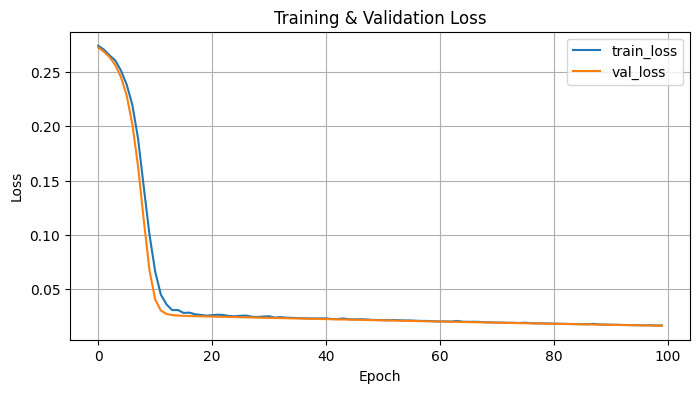

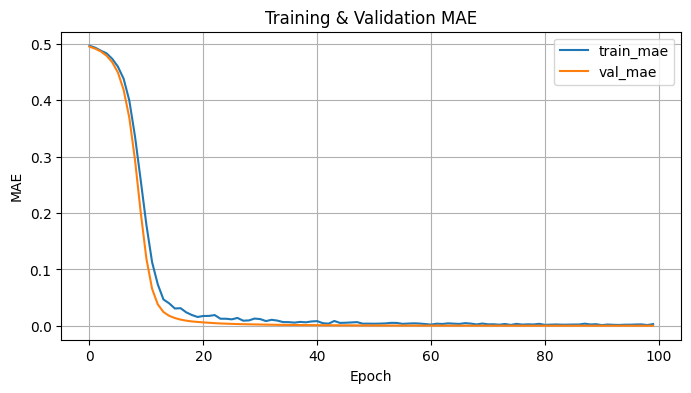

In [14]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(8, 4))
plt.plot(history.history['mae'],     label='train_mae')
plt.plot(history.history['val_mae'], label='val_mae')
plt.title('Training & Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()